# Ball Detection & Tracking — Data Preparation Pipeline

Import Libraries

In [1]:
import cv2
import numpy as np
import pandas as pd
import torch
from google.colab import drive
import os
import torch.nn as nn


Mount Google Drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


Loading & Extracting the Data

In [3]:
!find /content/drive/MyDrive -iname "*TrackNetV2*"
!unzip -q "/content/drive/MyDrive/TrackNetV2.zip" -d /content/TrackNetV2

/content/drive/MyDrive/TrackNetV2.zip
/content/drive/MyDrive/TrackNetV2_extracted_frames


In [4]:
!find /content/TrackNetV2 -maxdepth 4 | head -30

/content/TrackNetV2
/content/TrackNetV2/TrackNetV2
/content/TrackNetV2/TrackNetV2/Professional
/content/TrackNetV2/TrackNetV2/Professional/match7
/content/TrackNetV2/TrackNetV2/Professional/match7/video
/content/TrackNetV2/TrackNetV2/Professional/match7/csv
/content/TrackNetV2/TrackNetV2/Professional/match16
/content/TrackNetV2/TrackNetV2/Professional/match16/video
/content/TrackNetV2/TrackNetV2/Professional/match16/csv
/content/TrackNetV2/TrackNetV2/Professional/match4
/content/TrackNetV2/TrackNetV2/Professional/match4/video
/content/TrackNetV2/TrackNetV2/Professional/match4/csv
/content/TrackNetV2/TrackNetV2/Professional/match17
/content/TrackNetV2/TrackNetV2/Professional/match17/video
/content/TrackNetV2/TrackNetV2/Professional/match17/csv
/content/TrackNetV2/TrackNetV2/Professional/match15
/content/TrackNetV2/TrackNetV2/Professional/match15/video
/content/TrackNetV2/TrackNetV2/Professional/match15/csv
/content/TrackNetV2/TrackNetV2/Professional/match9
/content/TrackNetV2/TrackNetV2

Inspect Labels

In [5]:
LABEL_DIR = "/content/TrackNetV2/TrackNetV2/Amateur/match1/csv/1_00_01_ball.csv"
label = pd.read_csv(LABEL_DIR)
label.head(20)

,Frame,Visibility,X,Y
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0
5,5,0,0,0
6,6,0,0,0
7,7,0,0,0
8,8,0,0,0
9,9,0,0,0


In [6]:
print(label['Visibility'].unique())
print(label.columns.tolist())

[0 1]
['Frame', 'Visibility', 'X', 'Y']


Inspect Video Properties

In [7]:
IMG_PATH = "/content/TrackNetV2/TrackNetV2/Amateur/match1/video/1_00_01.mp4"
video = cv2.VideoCapture(IMG_PATH)
if not video.isOpened():
    print("Error: Could not open video.")
else:
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    fps    = video.get(cv2.CAP_PROP_FPS)
    print(f"Resolution : {width} X {height}")
    print(f"FPS:         {fps}")

Resolution : 1280 X 720
FPS:         30.0


In [8]:
!ls /content/TrackNetV2/TrackNetV2/Amateur/match1/video
!ls /content/TrackNetV2/TrackNetV2/Amateur/match1/csv

1_00_01.mp4  1_01_02.mp4  1_01_04.mp4  1_03_04.mp4  1_04_05.mp4
1_01_01.mp4  1_01_03.mp4  1_02_04.mp4  1_03_05.mp4  1_05_05.mp4
1_00_01_ball.csv  1_01_03_ball.csv  1_03_04_ball.csv  1_05_05_ball.csv
1_01_01_ball.csv  1_01_04_ball.csv  1_03_05_ball.csv
1_01_02_ball.csv  1_02_04_ball.csv  1_04_05_ball.csv


Extract Frames from Videos

In [9]:
VIDEOS_DIR = "/content/TrackNetV2/TrackNetV2/"
FRAMES_BASE_OUTPUT = "/content/drive/MyDrive/TrackNetV2_extracted_frames"

def extract_frames(video_path, output_dir):
  os.makedirs(output_dir, exist_ok=True)

  # Check if frames are already extracted
  existing_frames = [f for f in os.listdir(output_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  if existing_frames:
      print(f"Frames already exist in {output_dir}. Skipping extraction.")
      return len(existing_frames)

  cap = cv2.VideoCapture(video_path)
  if not cap.isOpened():
      print(f"Error: Could not open video {video_path}")
      return 0

  print(f"Extracting frames from: {video_path} to {output_dir}")
  i = 0
  while True:
    ret, frame = cap.read()
    if not ret:
      break
    cv2.imwrite(os.path.join(output_dir, f"frame_{i:05d}.jpg"), frame)
    i += 1
  cap.release()
  print(f"Extracted {i} frames.")
  return i

for dirpath, dirnames, filenames in os.walk(VIDEOS_DIR):
  for filename in filenames:
    if filename.endswith(".mp4"):
      video_file_path = os.path.join(dirpath, filename)
      relative_path = os.path.relpath(video_file_path, VIDEOS_DIR)
      video_output_dir = os.path.join(FRAMES_BASE_OUTPUT, os.path.dirname(relative_path), os.path.splitext(filename)[0])

      extract_frames(video_file_path, video_output_dir)

Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/1_12_13. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/2_05_03. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/2_14_15. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/1_02_01. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match7/video/3_08_05. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match16/video/2_08_08. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Professional/match16/video/3_14_09. Skipping extraction.
Frames already exist in /content/drive/MyDrive/TrackNetV2_extracted_frames/Profes

Build Sliding-Window Frame Triplets (Truncated to CSV Length)

In [10]:
WINDOW_SIZE = 3

samples = []

for dirpath, dirnames, filenames in os.walk(FRAMES_BASE_OUTPUT):
    if dirnames:
        continue

    frame_files = sorted(f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png")))
    if not frame_files:
        continue

    rel_path = os.path.relpath(dirpath, FRAMES_BASE_OUTPUT)
    parts = rel_path.split(os.sep)
    clip_name = parts[-1]
    csv_parts = ["csv" if p == "video" else p for p in parts[:-1]]
    csv_path = os.path.join(VIDEOS_DIR, *csv_parts, f"{clip_name}_ball.csv")

    if not os.path.exists(csv_path):
        continue

    clip_labels = pd.read_csv(csv_path)

    n = len(clip_labels)
    frame_paths = [os.path.join(dirpath, f) for f in frame_files[:n]]

    for i in range(len(frame_paths) - WINDOW_SIZE + 1):
        frame_path_1, frame_path_2, frame_path_3 = frame_paths[i], frame_paths[i + 1], frame_paths[i + 2]
        label_1 = tuple(clip_labels.iloc[i][["Visibility", "X", "Y"]])
        label_2 = tuple(clip_labels.iloc[i + 1][["Visibility", "X", "Y"]])
        label_3 = tuple(clip_labels.iloc[i + 2][["Visibility", "X", "Y"]])
        samples.append((frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3))

print(f"Built {len(samples)} sliding-window triplets from {FRAMES_BASE_OUTPUT}")

Built 90255 sliding-window triplets from /content/drive/MyDrive/TrackNetV2_extracted_frames


In [11]:
class TrackNetDataset(torch.utils.data.Dataset):
    def __init__(self, samples, resize_to=(512, 288)):
      self.samples = samples
      self.resize_to = resize_to

    def __len__(self):
      return len(self.samples)

    def __getitem__(self, idx):
      frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3 = self.samples[idx]

      new_w, new_h = self.resize_to
      images = []
      labels = []
      for frame_path, label in zip((frame_path_1, frame_path_2, frame_path_3), (label_1, label_2, label_3)):
        image = cv2.imread(frame_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]
        image = cv2.resize(image, self.resize_to, interpolation=cv2.INTER_AREA)
        images.append(image.transpose(2, 0, 1))

        visibility, x, y = label
        scale_x = new_w / orig_w
        scale_y = new_h / orig_h
        labels.append((visibility, x * scale_x, y * scale_y))

      images = np.concatenate(images, axis=0)
      labels = np.array(labels, dtype=np.float32)

      return torch.from_numpy(images), torch.from_numpy(labels)

In [12]:
from matplotlib import pyplot as plt

dataset = TrackNetDataset(samples)
images, labels = dataset[15]


print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: torch.Size([9, 288, 512])
Labels shape: torch.Size([3, 3])


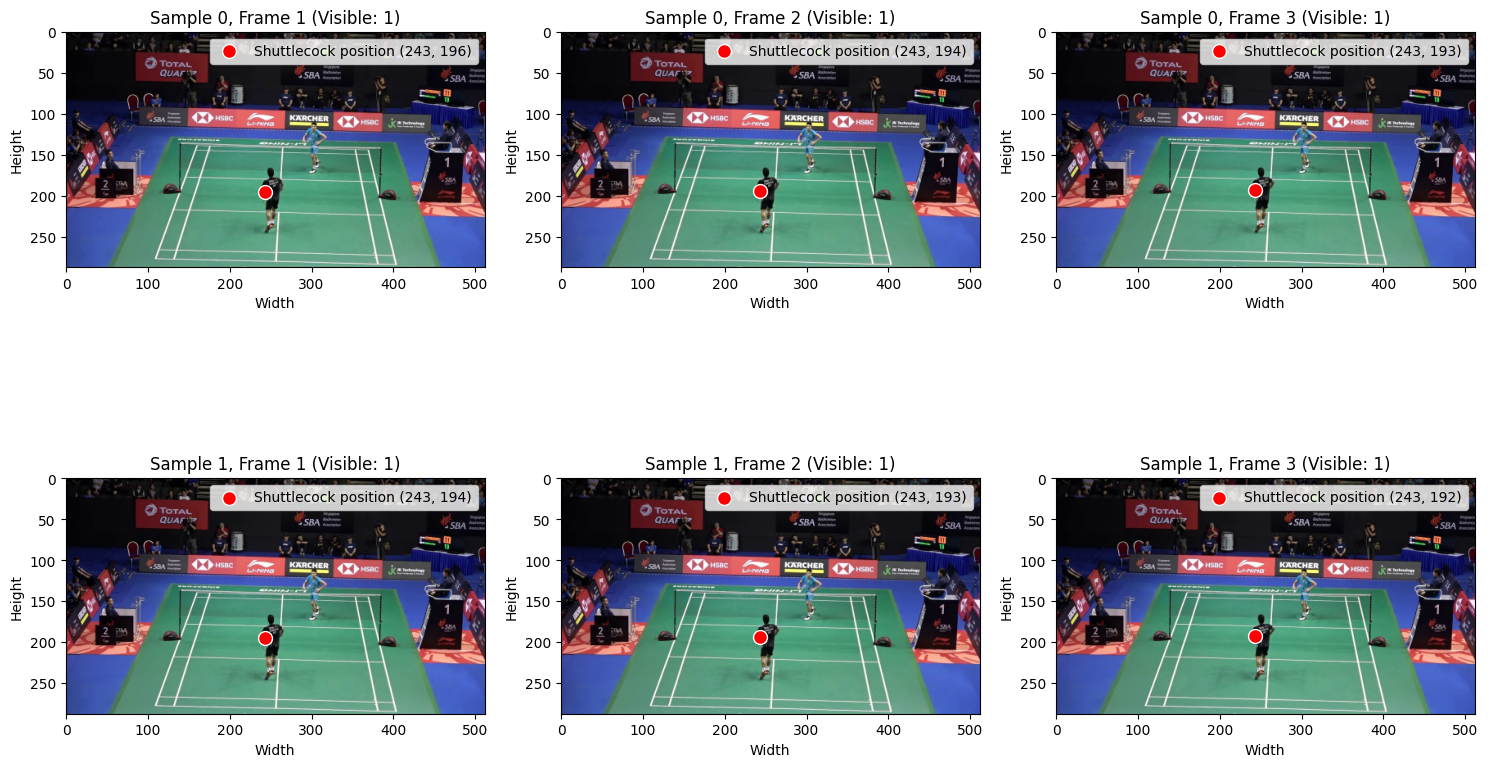

In [13]:
import math

cols = 3
num_samples_to_fetch = 2
total_frames_to_plot = num_samples_to_fetch * 3
rows = math.ceil(total_frames_to_plot / cols)
plt.figure(figsize=(cols * 5, rows * 5))

frame_counter = 0
for sample_idx in range(num_samples_to_fetch):
    if sample_idx >= len(dataset):
        print(f"Warning: Dataset only has {len(dataset)} samples. Plotting fewer than requested.")
        break

    images_from_sample, labels_from_sample = dataset[sample_idx]

    for i in range(3):
        if frame_counter >= total_frames_to_plot:
            break

        img_to_show = images_from_sample[i*3:(i*3)+3].permute(1, 2, 0).numpy()
        visibility, x, y = labels_from_sample[i].tolist()

        plt.subplot(rows, cols, frame_counter + 1)
        plt.imshow(img_to_show)
        plt.title(f"Sample {sample_idx}, Frame {i+1} (Visible: {int(visibility)})")
        plt.xlabel("Width")
        plt.ylabel("Height")


        if visibility == 1:
            plt.scatter(x, y, color='red', marker='o', s=100, edgecolors='white', linewidth=1, label=f'Shuttlecock position ({int(x)}, {int(y)})')
            plt.legend(loc='upper right')

        frame_counter += 1
    if frame_counter >= total_frames_to_plot:
        break

plt.tight_layout()
plt.show()

Generate Gaussian Heatmaps for Ball Position

In [14]:
HEATMAP_SIGMA = 5

def generate_heatmap(x, y, visibility, H, W, sigma=HEATMAP_SIGMA):
    if not visibility:
        return np.zeros((H, W), dtype=np.float32)

    cols, rows = np.meshgrid(np.arange(W), np.arange(H))
    heatmap = np.exp(-((cols - x) ** 2 + (rows - y) ** 2) / (2 * sigma ** 2))
    return heatmap.astype(np.float32)

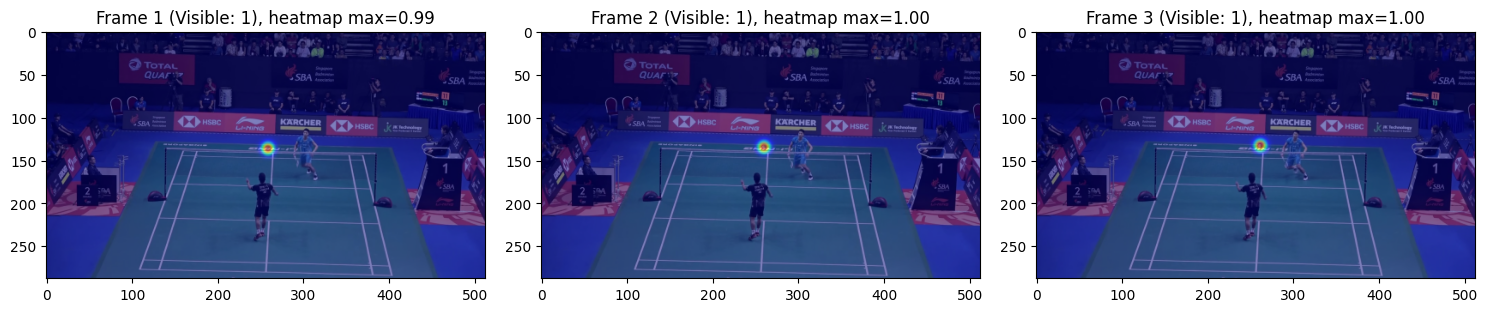

In [15]:
images, labels = dataset[15]
H, W = dataset.resize_to[1], dataset.resize_to[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    visibility, x, y = labels[i].tolist()
    heatmap = generate_heatmap(x, y, visibility, H, W)

    img_to_show = images[i*3:(i*3)+3].permute(1, 2, 0).numpy()
    ax.imshow(img_to_show)
    ax.imshow(heatmap, cmap='jet', alpha=0.5)
    ax.set_title(f"Frame {i+1} (Visible: {int(visibility)}), heatmap max={heatmap.max():.2f}")

plt.tight_layout()
plt.show()

VGG-Style Encoder-Decoder (TrackNetV2)

In [16]:
class TrackNetV2(nn.Module):
    def __init__(self):
        super().__init__()

        # ---- Encoder ----
        # Each block split into conv-layers and pool separately,
        # so we can grab the pre-pool output for skip connections.
        self.enc1_conv = nn.Sequential(
            nn.Conv2d(9, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2, 2)

        self.enc2_conv = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2, 2)

        self.enc3_conv = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool3 = nn.MaxPool2d(2, 2)

        self.enc4_conv = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.pool4 = nn.MaxPool2d(2, 2)

        # ---- Decoder ----
        # dec*_conv in_channels = upsampled channels + concatenated skip channels
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1_conv = nn.Sequential(
            nn.Conv2d(768, 256, 3, padding=1), nn.ReLU(inplace=True),  # 256 (up1) + 512 (e4 skip)
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True),
        )

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2_conv = nn.Sequential(
            nn.Conv2d(384, 128, 3, padding=1), nn.ReLU(inplace=True),  # 128 (up2) + 256 (e3 skip)
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True),
        )

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3_conv = nn.Sequential(
            nn.Conv2d(192, 64, 3, padding=1), nn.ReLU(inplace=True),  # 64 (up3) + 128 (e2 skip)
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True),
        )

        self.up4 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        # Raw logits — no activation. Loss is BCEWithLogitsLoss, which applies
        # sigmoid internally (more numerically stable than a separate Sigmoid + BCE).
        self.final_conv = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, x):
        # Encoder — keep pre-pool outputs for skip connections
        e1 = self.enc1_conv(x)          # (64, 288, 512)
        p1 = self.pool1(e1)             # (64, 144, 256)

        e2 = self.enc2_conv(p1)         # (128, 144, 256)
        p2 = self.pool2(e2)             # (128, 72, 128)

        e3 = self.enc3_conv(p2)         # (256, 72, 128)
        p3 = self.pool3(e3)             # (256, 36, 64)

        e4 = self.enc4_conv(p3)         # (512, 36, 64)
        p4 = self.pool4(e4)             # (512, 18, 32)  <- bottleneck

        # Decoder — upsample, concat with matching skip, conv
        d1 = self.up1(p4)                          # (256, 36, 64)
        d1 = torch.cat([d1, e4], dim=1)             # (768, 36, 64)
        d1 = self.dec1_conv(d1)                     # (256, 36, 64)

        d2 = self.up2(d1)                           # (128, 72, 128)
        d2 = torch.cat([d2, e3], dim=1)             # (384, 72, 128)
        d2 = self.dec2_conv(d2)                     # (128, 72, 128)

        d3 = self.up3(d2)                           # (64, 144, 256)
        d3 = torch.cat([d3, e2], dim=1)             # (192, 144, 256)
        d3 = self.dec3_conv(d3)                     # (64, 144, 256)

        d4 = self.up4(d3)                           # (32, 288, 512)
        out = self.final_conv(d4)                   # (3, 288, 512) raw logits

        return out

Heatmap Target Wrapper — pairs each triplet's images with its 3-channel Gaussian heatmap target

In [17]:
class TrackNetHeatmapDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        self.W, self.H = base_dataset.resize_to

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        images, labels = self.base_dataset[idx]

        heatmaps = np.stack([
            generate_heatmap(x=labels[i, 1].item(), y=labels[i, 2].item(),
                              visibility=labels[i, 0].item(), H=self.H, W=self.W)
            for i in range(labels.shape[0])
        ], axis=0)

        return images.float(), torch.from_numpy(heatmaps)


heatmap_dataset = TrackNetHeatmapDataset(dataset)
sample_images, sample_targets = heatmap_dataset[15]
print(f"Images shape:  {sample_images.shape}")
print(f"Targets shape: {sample_targets.shape}, max={sample_targets.max():.2f}")

Images shape:  torch.Size([9, 288, 512])
Targets shape: torch.Size([3, 288, 512]), max=1.00


Model, Weighted BCE Loss, Optimizer, Tiny Overfit Subset

In [41]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TrackNetV2().to(DEVICE)

# Gaussian blobs (sigma=5) cover a small fraction of the 288x512 frame, so
# background pixels vastly outnumber ball pixels. pos_weight upweights the
# positive term of BCE to counter that imbalance. BCEWithLogitsLoss works
# fine against our continuous 0->1 Gaussian targets, not just hard 0/1 labels.
POS_WEIGHT = 10.0
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Tiny subset to sanity-check the model/loss/optimizer can overfit before
# committing to a full training run.
subset_indices = list(range(15, 30))
train_subset = torch.utils.data.Subset(heatmap_dataset, subset_indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=4, shuffle=True)

print(f"Device: {DEVICE}")
print(f"Subset size: {len(train_subset)}")

Device: cuda
Subset size: 15


In [42]:
print(model.final_conv)

Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))


Training Loop — Overfit Sanity Check on the Tiny Subset

In [43]:
NUM_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 5

best_loss = float('inf')
patience_counter = 0

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - Loss: {avg_epoch_loss:.4f}")

    # Early stopping logic
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter > EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after {epoch + 1} epochs due to no improvement in loss for {EARLY_STOPPING_PATIENCE} consecutive epochs.")
        break

Epoch 1/200 - Loss: 0.4369
Epoch 2/200 - Loss: 0.1787
Epoch 3/200 - Loss: 0.1416
Epoch 4/200 - Loss: 0.1128
Epoch 5/200 - Loss: 0.1067
Epoch 6/200 - Loss: 0.0724
Epoch 7/200 - Loss: 0.0564
Epoch 8/200 - Loss: 0.0504
Epoch 9/200 - Loss: 0.0432
Epoch 10/200 - Loss: 0.0353
Epoch 11/200 - Loss: 0.0301
Epoch 12/200 - Loss: 0.0322
Epoch 13/200 - Loss: 0.0251
Epoch 14/200 - Loss: 0.0241
Epoch 15/200 - Loss: 0.0208
Epoch 16/200 - Loss: 0.0164
Epoch 17/200 - Loss: 0.0143
Epoch 18/200 - Loss: 0.0120
Epoch 19/200 - Loss: 0.0116
Epoch 20/200 - Loss: 0.0116
Epoch 21/200 - Loss: 0.0114
Epoch 22/200 - Loss: 0.0119
Epoch 23/200 - Loss: 0.0123
Epoch 24/200 - Loss: 0.0120
Epoch 25/200 - Loss: 0.0117
Epoch 26/200 - Loss: 0.0107
Epoch 27/200 - Loss: 0.0107
Epoch 28/200 - Loss: 0.0101
Epoch 29/200 - Loss: 0.0103
Epoch 30/200 - Loss: 0.0098
Epoch 31/200 - Loss: 0.0092
Epoch 32/200 - Loss: 0.0090
Epoch 33/200 - Loss: 0.0087
Epoch 34/200 - Loss: 0.0086
Epoch 35/200 - Loss: 0.0084
Epoch 36/200 - Loss: 0.0082
E

In [44]:
model = TrackNetV2().to(DEVICE)
x = torch.randn(1, 9, 288, 512).to(DEVICE)
out = model(x)
print(out.shape)

torch.Size([1, 3, 288, 512])


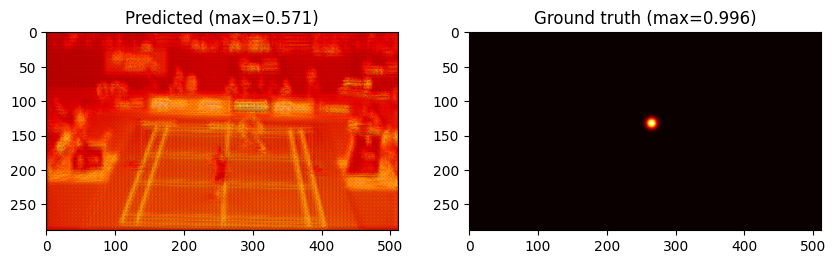

In [45]:
model.eval()
with torch.no_grad():
    images, targets = next(iter(train_loader))  # 'targets' now correctly refers to ground truth heatmaps
    images = images.to(DEVICE)
    logits = model(images)
    preds = torch.sigmoid(logits)  # apply sigmoid manually now, since it's not in the model anymore

# pick one sample, one frame within it (say frame index 1 of the 3)
sample_idx = 0
frame_idx = 1

pred_heatmap = preds[sample_idx, frame_idx].cpu().numpy()
target_heatmap = targets[sample_idx, frame_idx].cpu().numpy()  # Use 'targets' here

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(pred_heatmap, cmap='hot')
axes[0].set_title(f"Predicted (max={pred_heatmap.max():.3f})")
axes[1].imshow(target_heatmap, cmap='hot')
axes[1].set_title(f"Ground truth (max={target_heatmap.max():.3f})")
plt.show()

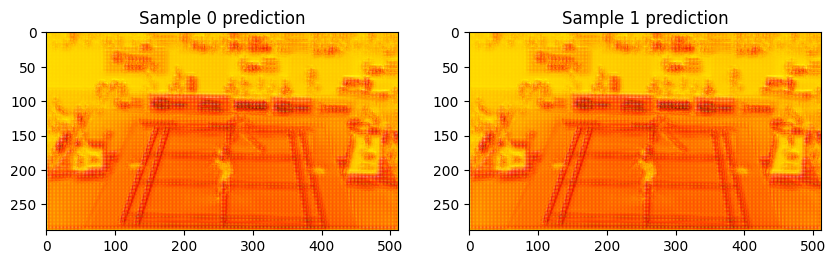

In [33]:
model.eval()
with torch.no_grad():
    logits = model(images)  # your same tiny batch
    preds = torch.sigmoid(logits)

# compare predicted heatmaps for sample 0 vs sample 1 (different ball locations)
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(preds[0, 1].cpu().numpy(), cmap='hot')
axes[0].set_title("Sample 0 prediction")
axes[1].imshow(preds[1, 1].cpu().numpy(), cmap='hot')
axes[1].set_title("Sample 1 prediction")
plt.show()